<H1>Assignment: Linear Regression Techniques</H1>

<b>Objective:</b>

To apply various linear regression techniques on the scikit-learn diabetes dataset to predict disease progression. The exercises will cover the normal equation, leveraging scikit-learn's stochastic gradient descent (SGD) implementation, and the scikit-learn linear regression model.

<b>Dataset:</b>

Scikit-learn diabetes dataset, which has been mean-centered and scaled. Features include age, BMI, blood pressure, etc.

<H2>Exercises:</H2>

Use only the BMI feature for all tasks.

<b>Task 1.1: Normal Equation</b>
<ol>
  <li>Implement the normal equation to find the optimal parameters for the linear regression model.
Use the equation $\theta = (X^T X)^{-1} X^T y$ to calculate $\theta$.</li>
  <li>Evaluate the model's performance using the mean squared error (MSE) metric (see sklearn.metrics).</li>
  <li>Plot the regression model including the data.</li>
</ol>

<b>Task 1.2: Scikit-learn's SGDRegressor</b>
<ol>
  <li>Utilize scikit-learn's SGDRegressor for linear regression.</li>
  <li>Initialize $\theta$ randomly (handled internally by scikit-learn), and the model updates $\theta$ using the gradient of the loss function with respect to each training example individually.</li>
   <li>Iterate until convergence or for a fixed number of epochs (configurable via the max_iter and tol parameters).</li>
   <li>Evaluate the model using the mean squared error (MSE) metric and compare the results with the normal equation.</li>
</ol>
<b>Task 1.3: Scikit-learn's LinearRegression</b>
<ol>
  <li>Use scikit-learn's LinearRegression model to fit the diabetes dataset.</li>
  <li>Evaluate the model using cross-validation and calculate the average MSE.</li>
</ol>


Theta: [152.13348416 949.43526038]
MSE: 3890.4565854612724


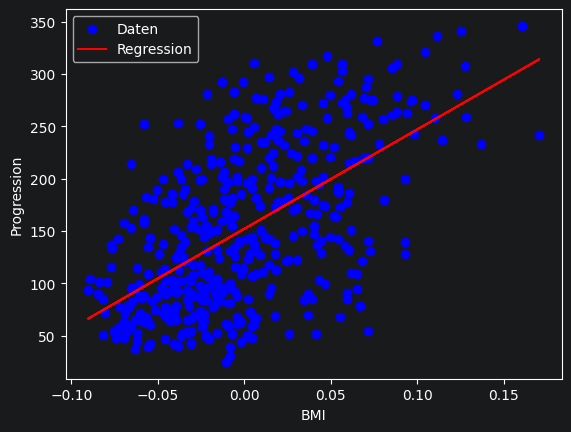

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error

diabetes = load_diabetes()

X = diabetes.data[:, 2].reshape(-1, 1)

y = diabetes.target

X_b = np.c_[np.ones((X.shape[0], 1)), X]

theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Theta:", theta_best)

y_pred = X_b.dot(theta_best)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

plt.scatter(X, y, color='blue', label="Daten")
plt.plot(X, y_pred, color='red', label="Regression")
plt.xlabel("BMI")
plt.ylabel("Progression")
plt.legend()
plt.show()

In [2]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=10000, tol=1e-3, random_state=42)

sgd.fit(X, y)

print("Theta0:", sgd.intercept_)
print("Theta1:", sgd.coef_)

y_pred_sgd = sgd.predict(X)

mse_sgd = mean_squared_error(y, y_pred_sgd)
print("MSE SGD:", mse_sgd)

Theta0: [152.11025718]
Theta1: [773.75477933]
MSE SGD: 3960.284345370657


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()

scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)

mse_scores = -scores

print("MSE pro Fold:", mse_scores)
print("Durchschnitt MSE:", mse_scores.mean())

MSE pro Fold: [3865.97147707 3996.89622667 3821.66280573 3705.91035198 4124.81539514]
Durchschnitt MSE: 3903.0512513175213
